In [1]:
from detectron2.config import get_cfg
from detectron2.projects.deeplab import add_deeplab_config
from mask2former import add_maskformer2_config

In [2]:
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

#cfg.merge_from_file('configs/swin/maskformer2_swin_base_384_bs16_50ep.yaml')
cfg.merge_from_file('configs/maskformer2_R50_bs16_50ep.yaml')
cfg.MODEL.RESNETS.NORM = "BN"
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_swin_large_IN21k_384_bs16_100ep/model_final_f07440.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_swin_base_384_bs16_50ep/model_final_f6e0f6.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/panoptic/maskformer2_R50_bs16_50ep/model_final_94dc52.pkl'
#cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl'
cfg.MODEL.WEIGHTS = './fullelasticm2f_ckpt.pth'
#cfg.MODEL.WEIGHTS = './model_final_3c8ec9.pkl'
cfg.OUTPUT_DIR = "./test_output/"
cfg.MODEL.DEVICE = "cuda"

In [3]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: True
  NUM_WORKERS: 4
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('coco_2017_val',)
  TRAIN: ('coco_2017_train',)
GLOBAL:
  HACK: 1.0
INPUT:
  COLOR_AUG_SSD: False
  CROP:
    ENABLED: False
    SINGLE_CATEGORY_MAX_AREA: 1.0
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  DATASET_MAPPER_NAME: coco_instance_lsj
  FORMAT: RGB
  IMAGE_SIZE: 1024
  MASK_FORMAT: polygon
  MAX_SCALE: 2.0
  MAX_SIZE_TEST: 1333
  MAX_SIZE_TRAIN: 1333
  MIN_SCALE: 0.1
  MIN_SIZE_TEST: 800
  MIN_SIZE_TRAIN: (800,)
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
  SIZE_DIVISIBILITY: -1
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32, 64, 128, 

In [4]:
import torch
torch.cuda.set_device(1)

In [5]:
cfg.freeze()

In [6]:
from detectron2.engine import (
    DefaultWSTrainer,
)
class Trainer(DefaultWSTrainer):
    """
    Extension of the Trainer class adapted to MaskFormer.
    """

    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        """
        Create evaluator(s) for a given dataset.
        This uses the special metadata "evaluator_type" associated with each
        builtin dataset. For your own dataset, you can simply create an
        evaluator manually in your script and do not have to worry about the
        hacky if-else logic here.
        """
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        evaluator_list = []
        evaluator_type = MetadataCatalog.get(dataset_name).evaluator_type
        # semantic segmentation
        if evaluator_type in ["sem_seg", "ade20k_panoptic_seg"]:
            evaluator_list.append(
                SemSegEvaluator(
                    dataset_name,
                    distributed=True,
                    output_dir=output_folder,
                )
            )
        # instance segmentation
        if evaluator_type == "coco":
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        # panoptic segmentation
        if evaluator_type in [
            "coco_panoptic_seg",
            "ade20k_panoptic_seg",
            "cityscapes_panoptic_seg",
            "mapillary_vistas_panoptic_seg",
        ]:
            if cfg.MODEL.MASK_FORMER.TEST.PANOPTIC_ON:
                evaluator_list.append(COCOPanopticEvaluator(dataset_name, output_folder))
        # COCO
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(COCOEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "coco_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Mapillary Vistas
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        if evaluator_type == "mapillary_vistas_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
            evaluator_list.append(SemSegEvaluator(dataset_name, distributed=True, output_dir=output_folder))
        # Cityscapes
        if evaluator_type == "cityscapes_instance":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesInstanceEvaluator(dataset_name)
        if evaluator_type == "cityscapes_sem_seg":
            assert (
                torch.cuda.device_count() > comm.get_rank()
            ), "CityscapesEvaluator currently do not work with multiple machines."
            return CityscapesSemSegEvaluator(dataset_name)
        if evaluator_type == "cityscapes_panoptic_seg":
            if cfg.MODEL.MASK_FORMER.TEST.SEMANTIC_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesSemSegEvaluator(dataset_name))
            if cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
                assert (
                    torch.cuda.device_count() > comm.get_rank()
                ), "CityscapesEvaluator currently do not work with multiple machines."
                evaluator_list.append(CityscapesInstanceEvaluator(dataset_name))
        # ADE20K
        if evaluator_type == "ade20k_panoptic_seg" and cfg.MODEL.MASK_FORMER.TEST.INSTANCE_ON:
            evaluator_list.append(InstanceSegEvaluator(dataset_name, output_dir=output_folder))
        # LVIS
        if evaluator_type == "lvis":
            return LVISEvaluator(dataset_name, output_dir=output_folder)
        if len(evaluator_list) == 0:
            raise NotImplementedError(
                "no Evaluator for the dataset {} with the type {}".format(
                    dataset_name, evaluator_type
                )
            )
        elif len(evaluator_list) == 1:
            return evaluator_list[0]
        return DatasetEvaluators(evaluator_list)

    @classmethod
    def build_train_loader(cls, cfg):
        # Semantic segmentation dataset mapper
        if cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_semantic":
            mapper = MaskFormerSemanticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Panoptic segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_panoptic":
            mapper = MaskFormerPanopticDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # Instance segmentation dataset mapper
        elif cfg.INPUT.DATASET_MAPPER_NAME == "mask_former_instance":
            mapper = MaskFormerInstanceDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco instance segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_instance_lsj":
            mapper = COCOInstanceNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        # coco panoptic segmentation lsj new baseline
        elif cfg.INPUT.DATASET_MAPPER_NAME == "coco_panoptic_lsj":
            mapper = COCOPanopticNewBaselineDatasetMapper(cfg, True)
            return build_detection_train_loader(cfg, mapper=mapper)
        else:
            mapper = None
            return build_detection_train_loader(cfg, mapper=mapper)

    @classmethod
    def build_lr_scheduler(cls, cfg, optimizer):
        """
        It now calls :func:`detectron2.solver.build_lr_scheduler`.
        Overwrite it if you'd like a different scheduler.
        """
        return build_lr_scheduler(cfg, optimizer)

    @classmethod
    def build_optimizer(cls, cfg, model):
        weight_decay_norm = cfg.SOLVER.WEIGHT_DECAY_NORM
        weight_decay_embed = cfg.SOLVER.WEIGHT_DECAY_EMBED

        defaults = {}
        defaults["lr"] = cfg.SOLVER.BASE_LR
        defaults["weight_decay"] = cfg.SOLVER.WEIGHT_DECAY

        norm_module_types = (
            torch.nn.BatchNorm1d,
            torch.nn.BatchNorm2d,
            torch.nn.BatchNorm3d,
            torch.nn.SyncBatchNorm,
            # NaiveSyncBatchNorm inherits from BatchNorm2d
            torch.nn.GroupNorm,
            torch.nn.InstanceNorm1d,
            torch.nn.InstanceNorm2d,
            torch.nn.InstanceNorm3d,
            torch.nn.LayerNorm,
            torch.nn.LocalResponseNorm,
        )

        params: List[Dict[str, Any]] = []
        memo: Set[torch.nn.parameter.Parameter] = set()
        for module_name, module in model.named_modules():
            for module_param_name, value in module.named_parameters(recurse=False):
                if not value.requires_grad:
                    continue
                # Avoid duplicating parameters
                if value in memo:
                    continue
                memo.add(value)

                hyperparams = copy.copy(defaults)
                if "backbone" in module_name:
                    hyperparams["lr"] = hyperparams["lr"] * cfg.SOLVER.BACKBONE_MULTIPLIER
                if (
                    "relative_position_bias_table" in module_param_name
                    or "absolute_pos_embed" in module_param_name
                ):
                    print(module_param_name)
                    hyperparams["weight_decay"] = 0.0
                if isinstance(module, norm_module_types):
                    hyperparams["weight_decay"] = weight_decay_norm
                if isinstance(module, torch.nn.Embedding):
                    hyperparams["weight_decay"] = weight_decay_embed
                params.append({"params": [value], **hyperparams})

        def maybe_add_full_model_gradient_clipping(optim):
            # detectron2 doesn't have full model gradient clipping now
            clip_norm_val = cfg.SOLVER.CLIP_GRADIENTS.CLIP_VALUE
            enable = (
                cfg.SOLVER.CLIP_GRADIENTS.ENABLED
                and cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model"
                and clip_norm_val > 0.0
            )

            class FullModelGradientClippingOptimizer(optim):
                def step(self, closure=None):
                    all_params = itertools.chain(*[x["params"] for x in self.param_groups])
                    torch.nn.utils.clip_grad_norm_(all_params, clip_norm_val)
                    super().step(closure=closure)

            return FullModelGradientClippingOptimizer if enable else optim

        optimizer_type = cfg.SOLVER.OPTIMIZER
        if optimizer_type == "SGD":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.SGD)(
                params, cfg.SOLVER.BASE_LR, momentum=cfg.SOLVER.MOMENTUM
            )
        elif optimizer_type == "ADAMW":
            optimizer = maybe_add_full_model_gradient_clipping(torch.optim.AdamW)(
                params, cfg.SOLVER.BASE_LR
            )
        else:
            raise NotImplementedError(f"no optimizer type {optimizer_type}")
        if not cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE == "full_model":
            optimizer = maybe_add_gradient_clipping(cfg, optimizer)
        return optimizer

    @classmethod
    def test_with_TTA(cls, cfg, model):
        logger = logging.getLogger("detectron2.trainer")
        # In the end of training, run an evaluation with TTA.
        logger.info("Running inference with test-time augmentation ...")
        model = SemanticSegmentorWithTTA(cfg, model)
        evaluators = [
            cls.build_evaluator(
                cfg, name, output_folder=os.path.join(cfg.OUTPUT_DIR, "inference_TTA")
            )
            for name in cfg.DATASETS.TEST
        ]
        res = cls.test(cfg, model, evaluators)
        res = OrderedDict({k + "_TTA": v for k, v in res.items()})
        return res

In [7]:
import torch
import copy
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    DatasetEvaluators,
    LVISEvaluator,
    SemSegEvaluator,
    verify_results,
)
from mask2former import (
    COCOInstanceNewBaselineDatasetMapper,
    COCOPanopticNewBaselineDatasetMapper,
    InstanceSegEvaluator,
    MaskFormerInstanceDatasetMapper,
    MaskFormerPanopticDatasetMapper,
    MaskFormerSemanticDatasetMapper,
    SemanticSegmentorWithTTA,
    add_maskformer2_config,
)
from detectron2.data import MetadataCatalog, build_detection_train_loader
from detectron2.projects.deeplab import build_lr_scheduler



In [8]:
print(cfg.OUTPUT_DIR)
print(cfg.MODEL.WEIGHTS)
#print(cfg.MODEL.WEIGHTS)


./test_output/
./fullelasticm2f_ckpt.pth


In [9]:
import cv2
im = cv2.imread("./planetopview2.png")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

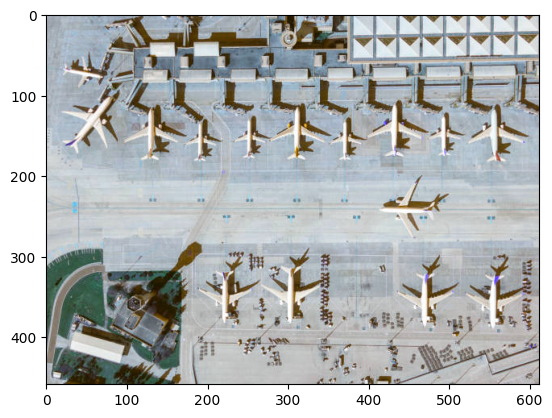

In [10]:
plt.imshow(im)

In [11]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
predictor.model.set_max_net()

#predictor.model.backbone.set_active_subnet([1,1,1,1])
outputs = predictor(im)

/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [12]:
!pwd
#print(predictor.model.backbone.layers)
all_keys = predictor.model.backbone.state_dict().keys()
#print(all_keys)
#print("layers.0.blocks.0.attn.relative_position_bias_table" in all_keys)
#print(predictor.model.backbone.layers[2].downsample)
#print(type(predictor.model.backbone.state_dict()))
#print(predictor.model.backbone.layers[2].blocks[0].attn.relative_position_bias_table.shape)
#'layers.2.blocks.0.attn.qkv.weight'
#print(predictor.model.backbone.layers[2].blocks.state_dict().keys())
#print(predictor.model)

/home/akhare39/animesh/wsobjdet


In [13]:
#torch.save(predictor.model.backbone, "ckpts/COCO_M2F_SWIN_B_InstanceSeg.pt")

In [14]:
#torch.save({"model":predictor.model.backbone.state_dict()}, "ckpts/COCO_M2F_SWIN_B_InstanceSeg_state_dict.pth")

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(550, 734, 3)


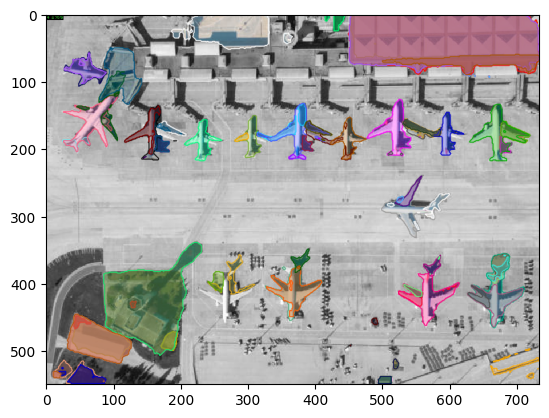

In [15]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [16]:
#!wget http://images.cocodataset.org/val2017/000000001584.jpg -q -O input.jpg
!wget http://images.cocodataset.org/val2017/000000005477.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")


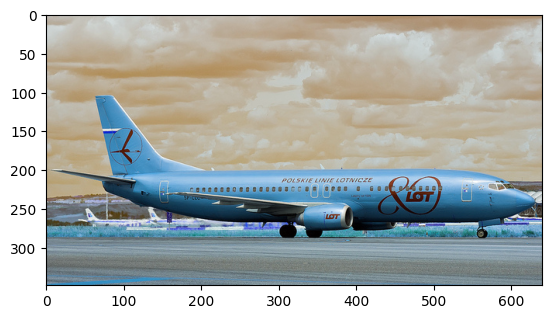

In [17]:
plt.imshow(im)

In [18]:
from detectron2.engine import DefaultPredictor
predictor = DefaultPredictor(cfg)
#predictor.model.backbone.set_active_subnet([0, 1, 3, 0])
outputs = predictor(im)


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

In [19]:
#print(outputs)

Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)
(418, 768, 3)


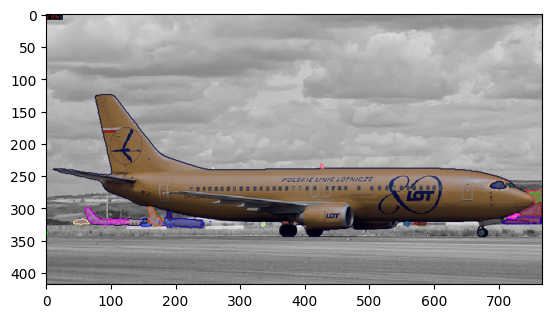

In [20]:
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import numpy as np

coco_metadata = MetadataCatalog.get("coco_2017_val_instance")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [21]:
trainer = Trainer(cfg)

[11/24 23:58:33 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


[11/24 23:58:45 d2.data.datasets.coco]: Loading datasets/coco/annotations/instances_train2017.json takes 12.18 seconds.
[11/24 23:58:45 d2.data.datasets.coco]: Loaded 118287 images in COCO format from datasets/coco/annotations/instances_train2017.json
[11/24 23:58:50 d2.data.build]: Removed 1021 images with no usable annotations. 117266 images left.
[11/24 23:58:53 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 257253       |   bicycle    | 7056         |      car      | 43533        |
|  motorcycle   | 8654         |   airplane   | 5129         |      bus      | 6061         |
|     train     | 4570         |    truck     | 9970         |     boat      | 10576        |
| traffic light | 12842        | fire hydrant | 1865         |   stop sign   | 1983         |
|

In [22]:
import os
from detectron2.checkpoint import DetectionCheckpointer

model = Trainer.build_model(cfg)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])
DetectionCheckpointer(model, save_dir=cfg.OUTPUT_DIR).resume_or_load(
    cfg.MODEL.WEIGHTS, resume=True
)
print(model.backbone.stem.conv1.weight[0, 0, 0, :])

[11/24 23:58:57 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(


tensor([-0.0184,  0.0068, -0.0273, -0.0257,  0.0279,  0.0244, -0.0033],
       device='cuda:1', grad_fn=<SliceBackward0>)
[11/24 23:58:57 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./fullelasticm2f_ckpt.pth ...


/home/akhare39/miniconda3/lib/python3.9/site-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.

tensor([ 0.0091,  0.0094, -0.0149, -0.0203, -0.0310, -0.0294, -0.0490],
       device='cuda:1', grad_fn=<SliceBackward0>)


In [23]:
#print(model.backbone.stem.conv1.norm.weight)

In [24]:
import copy
import torch.nn.functional as F
import torch.nn as nn
import random
import torch


class AverageMeter(object):
    """
    Computes and stores the average and current value
    Copied from: https://github.com/pytorch/examples/blob/master/imagenet/main.py
    """

    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#both group norm and batch norm updated
def set_running_statistics(model, data_loader):
    bn_mean = {}
    bn_var = {}

    gn_mean = {}
    gn_var = {}
    
    forward_model = copy.deepcopy(model)
    for name, m in forward_model.named_modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_mean[name] = AverageMeter()
            bn_var[name] = AverageMeter()

            def new_forward(bn, mean_est, var_est):
                def lambda_forward(x):
                    batch_mean = (
                        x.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )  # 1, C, 1, 1
                    batch_var = (x - batch_mean) * (x - batch_mean)
                    batch_var = (
                        batch_var.mean(0, keepdim=True)
                        .mean(2, keepdim=True)
                        .mean(3, keepdim=True)
                    )

                    batch_mean = torch.squeeze(batch_mean)
                    batch_var = torch.squeeze(batch_var)

                    mean_est.update(batch_mean.data, x.size(0))
                    var_est.update(batch_var.data, x.size(0))

                    # bn forward using calculated mean & var
                    _feature_dim = batch_mean.size(0)
                    return F.batch_norm(
                        x,
                        batch_mean,
                        batch_var,
                        bn.weight[:_feature_dim],
                        bn.bias[:_feature_dim],
                        False,
                        0.0,
                        bn.eps,
                    )

                return lambda_forward

            m.forward = new_forward(m, bn_mean[name], bn_var[name])
    
    if len(bn_mean) == 0:
        # skip if there is no batch normalization layers in the network
        return

    with torch.no_grad():
        count = 1
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = True
        for input_images in data_loader:
            forward_model(input_images)
            count+=1
            if count >= 2500:
                break
            if count % 50 == 0:
                print(count)
        #DynamicBatchNorm2d.SET_RUNNING_STATISTICS = False

    for name, m in model.named_modules():
        if name in bn_mean and bn_mean[name].count > 0:
            if "backbone" not in name:
                print("reported")
            feature_dim = bn_mean[name].avg.size(0)
            assert isinstance(m, nn.BatchNorm2d)
            m.running_mean.data[:feature_dim].copy_(bn_mean[name].avg)
            m.running_var.data[:feature_dim].copy_(bn_var[name].avg)

In [25]:
def count_parameters(model, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        #print(name)
        if not check_grad or (check_grad and parameter.requires_grad):
            count += parameter.numel()
    return count

In [26]:
total_num_param = count_parameters(model)
print("total params", total_num_param)
          
def maskformertransformer_param_count_helper(name, param, pixel_decoder_depth, transformer_decoder_depth):
    max_pixel_depth = 6+(pixel_decoder_depth-2)-1
    max_transformer_depth = 9+(transformer_decoder_depth-2)-1
    if 'predictor' in name:
        if 'transformer_self_attention_layers' in name or 'transformer_cross_attention_layers' in name \
            or 'transformer_ffn_layers' in name:
            if int(name.split('.')[3]) <= max_transformer_depth:
                #print(name, int(name.split('.')[3]))
                return param.numel()
            else:
                return 0            
    elif 'pixel_decoder.transformer.encoder.layers' in name:
        if int(name.split('.')[5]) <= max_pixel_depth:
            #print(name, int(name.split('.')[5]))
            return param.numel()
        else:
            return 0
    return param.numel()
          
def count_parameters_small(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if '0' in name and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

def count_parameters_large(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

smallest_net_param = count_parameters_small(model, 0, 0)
print("smallest net params:", smallest_net_param)
print("precentage of total:", smallest_net_param/total_num_param)
print("percentage decrease:", (total_num_param-smallest_net_param)/total_num_param)
def count_parameters_middle(model, pixel_decoder_depth=2, transformer_decoder_depth=2, check_grad=False):
    count = 0
    for name, parameter in model.named_parameters():
        if 'backbone' in name and 'res2' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res3' in name:
            if ('0' in name or '.1.' in name or '.2.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res4' in name:
            if ('0' in name or '.1.' in name or '.2.' in name or '.3.' in name or '.4.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif 'backbone' in name and 'res5' in name:
            if ('0' in name or '.1.' in name) and parameter.requires_grad:
                #print(name)
                count += parameter.numel()
        elif not check_grad or (check_grad and parameter.requires_grad):
            count += maskformertransformer_param_count_helper(name, parameter, pixel_decoder_depth, \
                transformer_decoder_depth)
    return count

middle_net_param = count_parameters_middle(model, 1, 1)
print("number of param in middle network:", middle_net_param)

smallest_backbone_param = count_parameters_small(model, 2, 2)
print("smallest backbone net params:", smallest_backbone_param)

middle_backbone_param = count_parameters_middle(model, 2, 2)
print("middle backbone net params:", middle_backbone_param)

smallest_pixel_decoder_max_rest_param = count_parameters_large(model, 0, 2)
print("max backbone, min pixel decoder, max transformer decoder net params:", smallest_pixel_decoder_max_rest_param)

smallest_transformer_decoder_max_rest_param = count_parameters_large(model, 2, 0)
print("max backbone, max pixel decoder, min transformer decoder net params:", smallest_transformer_decoder_max_rest_param)

middle_backbone_min_tf_decoder_param = count_parameters_middle(model, 2, 1)
print("middle backbone, max pixel decoder, min transformer decoder net params:", middle_backbone_min_tf_decoder_param)

total params 44023377
smallest net params: 27541009
precentage of total: 0.6255996444797953
percentage decrease: 0.3744003555202046
number of param in middle network: 35782193
smallest backbone net params: 32162897
middle backbone net params: 38093137
max backbone, min pixel decoder, max transformer decoder net params: 42558993
max backbone, max pixel decoder, min transformer decoder net params: 40865873
middle backbone, max pixel decoder, min transformer decoder net params: 36514385


In [27]:
print(model)

MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), strid

In [28]:
#train_data_loader = trainer.build_train_loader(cfg)

In [29]:
print(model.set_max_net())
print(model.backbone.runtime_depth)
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print(model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, train_data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'res2': 0, 'res3': 0, 'res4': 0, 'res5': 0}
0
0
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3


In [30]:
import warnings
warnings.filterwarnings('ignore')
print(model.sample_active_subnet())

{'backbone': {'depth_list': [0, 1, 2, 1]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [1]}}


In [50]:
#MAXIMUM NETWORK
print(model.set_max_net())
#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
50
100
res2 0 3
3 3
res3 0 4
4 4
res4 0 6
6 6
res5 0 3
3 3
[11/24 21:56:06 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/24 21:56:07 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[11/24 21:56:07 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[11/24 21:56:07 d2.data.common]: Serializing 5000 elements to byte tensors and concatenating them all ...
[11/24 21:56:07 d2.data.common]: Serialized dataset takes 19.10 MiB
[11/24 21:56:07 d2.evaluation.evaluator]: Start inference on 5000 batches
[11/24 21:56:09 d2.evaluation.evaluator]: Inference done 11/5000. Dataloading: 0.0011 s/iter. Inference: 0.0739 s/iter. Eval: 0.0770 s/iter. Total: 0.152

[11/24 21:59:32 d2.evaluation.evaluator]: Inference done 1424/5000. Dataloading: 0.0016 s/iter. Inference: 0.0747 s/iter. Eval: 0.0674 s/iter. Total: 0.1438 s/iter. ETA=0:08:34
[11/24 21:59:37 d2.evaluation.evaluator]: Inference done 1459/5000. Dataloading: 0.0016 s/iter. Inference: 0.0747 s/iter. Eval: 0.0674 s/iter. Total: 0.1438 s/iter. ETA=0:08:29
[11/24 21:59:43 d2.evaluation.evaluator]: Inference done 1494/5000. Dataloading: 0.0016 s/iter. Inference: 0.0746 s/iter. Eval: 0.0675 s/iter. Total: 0.1439 s/iter. ETA=0:08:24
[11/24 21:59:48 d2.evaluation.evaluator]: Inference done 1527/5000. Dataloading: 0.0016 s/iter. Inference: 0.0747 s/iter. Eval: 0.0677 s/iter. Total: 0.1441 s/iter. ETA=0:08:20
[11/24 21:59:53 d2.evaluation.evaluator]: Inference done 1562/5000. Dataloading: 0.0016 s/iter. Inference: 0.0747 s/iter. Eval: 0.0677 s/iter. Total: 0.1441 s/iter. ETA=0:08:15
[11/24 21:59:58 d2.evaluation.evaluator]: Inference done 1597/5000. Dataloading: 0.0016 s/iter. Inference: 0.0747 s

[11/24 22:03:21 d2.evaluation.evaluator]: Inference done 3029/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:04:41
[11/24 22:03:26 d2.evaluation.evaluator]: Inference done 3066/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0672 s/iter. Total: 0.1428 s/iter. ETA=0:04:36
[11/24 22:03:31 d2.evaluation.evaluator]: Inference done 3102/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0672 s/iter. Total: 0.1428 s/iter. ETA=0:04:31
[11/24 22:03:36 d2.evaluation.evaluator]: Inference done 3137/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0672 s/iter. Total: 0.1428 s/iter. ETA=0:04:26
[11/24 22:03:41 d2.evaluation.evaluator]: Inference done 3172/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:04:21
[11/24 22:03:46 d2.evaluation.evaluator]: Inference done 3209/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s

[11/24 22:07:09 d2.evaluation.evaluator]: Inference done 4627/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:00:53
[11/24 22:07:14 d2.evaluation.evaluator]: Inference done 4663/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:00:48
[11/24 22:07:19 d2.evaluation.evaluator]: Inference done 4698/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:00:43
[11/24 22:07:24 d2.evaluation.evaluator]: Inference done 4733/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:00:38
[11/24 22:07:29 d2.evaluation.evaluator]: Inference done 4768/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s/iter. Eval: 0.0673 s/iter. Total: 0.1429 s/iter. ETA=0:00:33
[11/24 22:07:34 d2.evaluation.evaluator]: Inference done 4805/5000. Dataloading: 0.0015 s/iter. Inference: 0.0740 s

[11/24 22:08:36 d2.evaluation.coco_evaluation]: Per-category segm AP: 
| category      | AP     | category     | AP     | category       | AP     |
|:--------------|:-------|:-------------|:-------|:---------------|:-------|
| person        | 35.958 | bicycle      | 9.914  | car            | 29.342 |
| motorcycle    | 19.864 | airplane     | 37.343 | bus            | 41.257 |
| train         | 43.668 | truck        | 18.690 | boat           | 9.487  |
| traffic light | 13.627 | fire hydrant | 48.249 | stop sign      | 39.798 |
| parking meter | 20.978 | bench        | 6.880  | bird           | 19.219 |
| cat           | 22.810 | dog          | 28.546 | horse          | 24.300 |
| sheep         | 25.253 | cow          | 31.707 | elephant       | 33.540 |
| bear          | 34.222 | zebra        | 48.369 | giraffe        | 47.007 |
| backpack      | 8.097  | umbrella     | 19.853 | handbag        | 6.343  |
| tie           | 14.942 | suitcase     | 20.593 | frisbee        | 42.019 |
| ski

In [31]:
#Smallest NETWORK
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
minnet_arch = {
    'pixel_decoder': {'depth_list': [0]},
    'predictor': {'depth_list': [0]}
}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 2
transformer decoder depth 2
50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[11/25 00:49:32 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/25 00:49:33 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 10777        |   bicycle    | 314          |      car      | 1918         |
|  motorcycle   | 367          |   airplane   | 143          |      bus      | 283          |
|     train     | 190          |    truck

[11/25 00:51:33 d2.evaluation.evaluator]: Inference done 673/5000. Dataloading: 0.0026 s/iter. Inference: 0.0597 s/iter. Eval: 0.1144 s/iter. Total: 0.1768 s/iter. ETA=0:12:45
[11/25 00:51:38 d2.evaluation.evaluator]: Inference done 701/5000. Dataloading: 0.0026 s/iter. Inference: 0.0597 s/iter. Eval: 0.1146 s/iter. Total: 0.1770 s/iter. ETA=0:12:40
[11/25 00:51:43 d2.evaluation.evaluator]: Inference done 729/5000. Dataloading: 0.0025 s/iter. Inference: 0.0595 s/iter. Eval: 0.1148 s/iter. Total: 0.1771 s/iter. ETA=0:12:36
[11/25 00:51:48 d2.evaluation.evaluator]: Inference done 760/5000. Dataloading: 0.0025 s/iter. Inference: 0.0593 s/iter. Eval: 0.1144 s/iter. Total: 0.1764 s/iter. ETA=0:12:28
[11/25 00:51:53 d2.evaluation.evaluator]: Inference done 789/5000. Dataloading: 0.0026 s/iter. Inference: 0.0592 s/iter. Eval: 0.1143 s/iter. Total: 0.1763 s/iter. ETA=0:12:22
[11/25 00:51:58 d2.evaluation.evaluator]: Inference done 819/5000. Dataloading: 0.0026 s/iter. Inference: 0.0592 s/iter.

[11/25 00:55:23 d2.evaluation.evaluator]: Inference done 1925/5000. Dataloading: 0.0023 s/iter. Inference: 0.0594 s/iter. Eval: 0.1191 s/iter. Total: 0.1810 s/iter. ETA=0:09:16
[11/25 00:55:28 d2.evaluation.evaluator]: Inference done 1951/5000. Dataloading: 0.0023 s/iter. Inference: 0.0594 s/iter. Eval: 0.1192 s/iter. Total: 0.1812 s/iter. ETA=0:09:12
[11/25 00:55:33 d2.evaluation.evaluator]: Inference done 1978/5000. Dataloading: 0.0024 s/iter. Inference: 0.0595 s/iter. Eval: 0.1193 s/iter. Total: 0.1813 s/iter. ETA=0:09:08
[11/25 00:55:38 d2.evaluation.evaluator]: Inference done 2005/5000. Dataloading: 0.0024 s/iter. Inference: 0.0595 s/iter. Eval: 0.1194 s/iter. Total: 0.1815 s/iter. ETA=0:09:03
[11/25 00:55:43 d2.evaluation.evaluator]: Inference done 2032/5000. Dataloading: 0.0024 s/iter. Inference: 0.0596 s/iter. Eval: 0.1195 s/iter. Total: 0.1816 s/iter. ETA=0:08:59
[11/25 00:55:48 d2.evaluation.evaluator]: Inference done 2059/5000. Dataloading: 0.0024 s/iter. Inference: 0.0596 s

[11/25 00:59:12 d2.evaluation.evaluator]: Inference done 3150/5000. Dataloading: 0.0024 s/iter. Inference: 0.0596 s/iter. Eval: 0.1212 s/iter. Total: 0.1834 s/iter. ETA=0:05:39
[11/25 00:59:17 d2.evaluation.evaluator]: Inference done 3177/5000. Dataloading: 0.0024 s/iter. Inference: 0.0596 s/iter. Eval: 0.1212 s/iter. Total: 0.1834 s/iter. ETA=0:05:34
[11/25 00:59:22 d2.evaluation.evaluator]: Inference done 3200/5000. Dataloading: 0.0024 s/iter. Inference: 0.0599 s/iter. Eval: 0.1212 s/iter. Total: 0.1837 s/iter. ETA=0:05:30
[11/25 00:59:27 d2.evaluation.evaluator]: Inference done 3227/5000. Dataloading: 0.0024 s/iter. Inference: 0.0599 s/iter. Eval: 0.1213 s/iter. Total: 0.1838 s/iter. ETA=0:05:25
[11/25 00:59:32 d2.evaluation.evaluator]: Inference done 3255/5000. Dataloading: 0.0024 s/iter. Inference: 0.0599 s/iter. Eval: 0.1213 s/iter. Total: 0.1838 s/iter. ETA=0:05:20
[11/25 00:59:37 d2.evaluation.evaluator]: Inference done 3279/5000. Dataloading: 0.0024 s/iter. Inference: 0.0599 s

[11/25 01:03:02 d2.evaluation.evaluator]: Inference done 4389/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s/iter. Eval: 0.1217 s/iter. Total: 0.1840 s/iter. ETA=0:01:52
[11/25 01:03:07 d2.evaluation.evaluator]: Inference done 4413/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s/iter. Eval: 0.1219 s/iter. Total: 0.1842 s/iter. ETA=0:01:48
[11/25 01:03:12 d2.evaluation.evaluator]: Inference done 4441/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s/iter. Eval: 0.1219 s/iter. Total: 0.1842 s/iter. ETA=0:01:42
[11/25 01:03:17 d2.evaluation.evaluator]: Inference done 4468/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s/iter. Eval: 0.1219 s/iter. Total: 0.1842 s/iter. ETA=0:01:37
[11/25 01:03:22 d2.evaluation.evaluator]: Inference done 4495/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s/iter. Eval: 0.1220 s/iter. Total: 0.1842 s/iter. ETA=0:01:33
[11/25 01:03:27 d2.evaluation.evaluator]: Inference done 4522/5000. Dataloading: 0.0023 s/iter. Inference: 0.0598 s

Loading and preparing results...
DONE (t=4.21s)
creating index...
index created!
[11/25 01:05:26 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[11/25 01:05:37 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 10.99 seconds.
[11/25 01:05:37 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[11/25 01:05:39 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.21 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.140
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.241
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.141
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.068
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.165
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.207
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.181
 Aver

OrderedDict([('bbox', {'AP': 0.0, 'AP50': 0.0, 'AP75': 0.0, 'APs': 0.0, 'APm': 0.0, 'APl': 0.0, 'AP-person': 0.0, 'AP-bicycle': 0.0, 'AP-car': 0.0, 'AP-motorcycle': 0.0, 'AP-airplane': 0.0, 'AP-bus': 0.0, 'AP-train': 0.0, 'AP-truck': 0.0, 'AP-boat': 0.0, 'AP-traffic light': 0.0, 'AP-fire hydrant': 0.0, 'AP-stop sign': 0.0, 'AP-parking meter': 0.0, 'AP-bench': 0.0, 'AP-bird': 0.0, 'AP-cat': 0.0, 'AP-dog': 0.0, 'AP-horse': 0.0, 'AP-sheep': 0.0, 'AP-cow': 0.0, 'AP-elephant': 0.0, 'AP-bear': 0.0, 'AP-zebra': 0.0, 'AP-giraffe': 0.0, 'AP-backpack': 0.0, 'AP-umbrella': 0.0, 'AP-handbag': 0.0, 'AP-tie': 0.0, 'AP-suitcase': 0.0, 'AP-frisbee': 0.0, 'AP-skis': 0.0, 'AP-snowboard': 0.0, 'AP-sports ball': 0.0, 'AP-kite': 0.0, 'AP-baseball bat': 0.0, 'AP-baseball glove': 0.0, 'AP-skateboard': 0.0, 'AP-surfboard': 0.0, 'AP-tennis racket': 0.0, 'AP-bottle': 0.0, 'AP-wine glass': 0.0, 'AP-cup': 0.0, 'AP-fork': 0.0, 'AP-knife': 0.0, 'AP-spoon': 0.0, 'AP-bowl': 0.0, 'AP-banana': 0.0, 'AP-apple': 0.0, 'AP

In [31]:
#Smallest NETWORK RESNET 50 BACKBONE max everything else
import warnings
warnings.filterwarnings('ignore')
model.set_max_net()
model.backbone.set_active_subnet(depth_list=[0, 0, 0, 0])
#model.sem_seg_head.pixel_decoder.transformer.set_active_subnet(depth_list=[0])
#model.sem_seg_head.predictor.set_active_subnet(depth_list=[0])
#minnet_arch = {
#    'pixel_decoder': {'depth_list': [0]},
#    'predictor': {'depth_list': [0]}
#}
#model.set_active_subnet(*minnet_arch)
print(model.backbone.runtime_depth)
print("pixel decoder depth", model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
print("transformer decoder depth", model.sem_seg_head.predictor.runtime_depth)

#set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

{'res2': 2, 'res3': 2, 'res4': 2, 'res5': 2}
pixel decoder depth 0
transformer decoder depth 0
res2 2 1
3 1
res3 2 2
4 2
res4 2 4
6 4
res5 2 1
3 1
[11/24 23:07:39 d2.data.datasets.coco]: Loaded 5000 images in COCO format from datasets/coco/annotations/instances_val2017.json
[11/24 23:07:40 d2.data.build]: Distribution of instances among all 80 categories:
|   category    | #instances   |   category   | #instances   |   category    | #instances   |
|:-------------:|:-------------|:------------:|:-------------|:-------------:|:-------------|
|    person     | 10777        |   bicycle    | 314          |      car      | 1918         |
|  motorcycle   | 367          |   airplane   | 143          |      bus      | 283          |
|     train     | 190          |    truck     | 414          |     boat      | 424          |
| traffic light | 634          | fire hydrant | 101          |   stop sign   | 75           |
| parking meter | 60           |    bench     | 411          |     bird      |

[11/24 23:09:44 d2.evaluation.evaluator]: Inference done 887/5000. Dataloading: 0.0017 s/iter. Inference: 0.0706 s/iter. Eval: 0.0666 s/iter. Total: 0.1390 s/iter. ETA=0:09:31
[11/24 23:09:49 d2.evaluation.evaluator]: Inference done 925/5000. Dataloading: 0.0017 s/iter. Inference: 0.0705 s/iter. Eval: 0.0664 s/iter. Total: 0.1388 s/iter. ETA=0:09:25
[11/24 23:09:54 d2.evaluation.evaluator]: Inference done 962/5000. Dataloading: 0.0017 s/iter. Inference: 0.0704 s/iter. Eval: 0.0665 s/iter. Total: 0.1388 s/iter. ETA=0:09:20
[11/24 23:09:59 d2.evaluation.evaluator]: Inference done 999/5000. Dataloading: 0.0017 s/iter. Inference: 0.0705 s/iter. Eval: 0.0664 s/iter. Total: 0.1387 s/iter. ETA=0:09:14
[11/24 23:10:05 d2.evaluation.evaluator]: Inference done 1036/5000. Dataloading: 0.0017 s/iter. Inference: 0.0705 s/iter. Eval: 0.0664 s/iter. Total: 0.1387 s/iter. ETA=0:09:09
[11/24 23:10:10 d2.evaluation.evaluator]: Inference done 1073/5000. Dataloading: 0.0017 s/iter. Inference: 0.0705 s/ite

[11/24 23:13:32 d2.evaluation.evaluator]: Inference done 2543/5000. Dataloading: 0.0016 s/iter. Inference: 0.0704 s/iter. Eval: 0.0662 s/iter. Total: 0.1382 s/iter. ETA=0:05:39
[11/24 23:13:38 d2.evaluation.evaluator]: Inference done 2580/5000. Dataloading: 0.0016 s/iter. Inference: 0.0704 s/iter. Eval: 0.0662 s/iter. Total: 0.1382 s/iter. ETA=0:05:34
[11/24 23:13:43 d2.evaluation.evaluator]: Inference done 2617/5000. Dataloading: 0.0016 s/iter. Inference: 0.0704 s/iter. Eval: 0.0662 s/iter. Total: 0.1382 s/iter. ETA=0:05:29
[11/24 23:13:48 d2.evaluation.evaluator]: Inference done 2651/5000. Dataloading: 0.0016 s/iter. Inference: 0.0704 s/iter. Eval: 0.0663 s/iter. Total: 0.1383 s/iter. ETA=0:05:24
[11/24 23:13:53 d2.evaluation.evaluator]: Inference done 2686/5000. Dataloading: 0.0016 s/iter. Inference: 0.0704 s/iter. Eval: 0.0664 s/iter. Total: 0.1384 s/iter. ETA=0:05:20
[11/24 23:13:58 d2.evaluation.evaluator]: Inference done 2722/5000. Dataloading: 0.0015 s/iter. Inference: 0.0705 s

[11/24 23:17:20 d2.evaluation.evaluator]: Inference done 4215/5000. Dataloading: 0.0015 s/iter. Inference: 0.0703 s/iter. Eval: 0.0656 s/iter. Total: 0.1375 s/iter. ETA=0:01:47
[11/24 23:17:25 d2.evaluation.evaluator]: Inference done 4255/5000. Dataloading: 0.0015 s/iter. Inference: 0.0703 s/iter. Eval: 0.0656 s/iter. Total: 0.1374 s/iter. ETA=0:01:42
[11/24 23:17:30 d2.evaluation.evaluator]: Inference done 4295/5000. Dataloading: 0.0015 s/iter. Inference: 0.0702 s/iter. Eval: 0.0655 s/iter. Total: 0.1373 s/iter. ETA=0:01:36
[11/24 23:17:36 d2.evaluation.evaluator]: Inference done 4335/5000. Dataloading: 0.0015 s/iter. Inference: 0.0702 s/iter. Eval: 0.0654 s/iter. Total: 0.1372 s/iter. ETA=0:01:31
[11/24 23:17:41 d2.evaluation.evaluator]: Inference done 4372/5000. Dataloading: 0.0015 s/iter. Inference: 0.0702 s/iter. Eval: 0.0654 s/iter. Total: 0.1372 s/iter. ETA=0:01:26
[11/24 23:17:46 d2.evaluation.evaluator]: Inference done 4409/5000. Dataloading: 0.0015 s/iter. Inference: 0.0702 s

Loading and preparing results...
DONE (t=4.06s)
creating index...
index created!
[11/24 23:19:31 d2.evaluation.fast_eval_api]: Evaluate annotation type *segm*
[11/24 23:19:40 d2.evaluation.fast_eval_api]: COCOeval_opt.evaluate() finished in 8.61 seconds.
[11/24 23:19:40 d2.evaluation.fast_eval_api]: Accumulating evaluation results...
[11/24 23:19:41 d2.evaluation.fast_eval_api]: COCOeval_opt.accumulate() finished in 1.01 seconds.
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.045
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.027
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.048
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.068
 Avera

In [ ]:
#Test max backbone, max transformer decoder, min pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
print(model.sem_seg_head.pixel_decoder.transformer.encoder.runtime_depth)
set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
#Test max backbone, min transformer decoder, max pixel decoder
model.backbone.set_max_net()
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
model.sem_seg_head.pixel_decoder.transformer.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
#Test middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([1])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([1])

set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
#set_running_statistics(trainer._trainer.model, train_data_loader)

In [ ]:
#Test middle resnet, min decoder max pixel decoder
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_active_subnet([0])
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([2])
set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
#Test resnet middle network
model.backbone.set_active_subnet(depth_list=[1, 1, 1, 1])
print(model.backbone.runtime_depth)
model.sem_seg_head.predictor.set_max_net()
print(model.sem_seg_head.predictor.runtime_depth)
model.sem_seg_head.pixel_decoder.transformer.set_max_net()

set_running_statistics(model, trainer._trainer.data_loader)
for name, stage in zip(model.backbone.stage_names, model.backbone.stages):
    depth_param = model.backbone.runtime_depth[name]
    print(name, model.backbone.runtime_depth[name], (len(stage) - depth_param))
    active_blocks = stage[:len(stage) - depth_param]
    print(len(stage), len(active_blocks))
res = Trainer.test(cfg, model)
print(res)

In [ ]:
'''print(type(train_data_loader.dataset.dataset), train_data_loader.dataset.dataset.sampler._size, train_data_loader.batch_size)
for item in train_data_loader:
    print(item[0].keys())
    print(trainer._trainer.model(item))'''

In [ ]:
print(cfg)

In [55]:
print(model.backbone.sample_active_subnet())
print(model.sample_active_subnet())
print(model.set_max_net())

{'depth_list': [2, 0, 1, 1]}
{'backbone': {'depth_list': [0, 1, 0, 1]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}
{'backbone': {'depth_list': [2, 2, 2, 2]}, 'pixel_decoder': {'depth_list': [2]}, 'predictor': {'depth_list': [2]}}


In [56]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

RuntimeError: CUDA error: an illegal memory access was encountered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
predictor = DefaultPredictor(cfg)
predictor.model.backbone.set_max_net()
#predictor.model.backbone.set_active_subnet([0, 0, 0, 0])
#predictor.model.sem_seg_head.pixel_decoder.transformer.set_active_subnet([0])
predictor.model.sem_seg_head.predictor.set_active_subnet([0])
print(predictor.model.sem_seg_head.predictor.runtime_depth)
outputs = predictor(im)
coco_metadata = MetadataCatalog.get("coco_2017_val_panoptic")

# Show panoptic/instance/semantic predictions: 
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#panoptic_result = v.draw_panoptic_seg(outputs["panoptic_seg"][0].to("cpu"), outputs["panoptic_seg"][1]).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
instance_result = v.draw_instance_predictions(outputs["instances"].to("cpu")).get_image()
v = Visualizer(im[:, :, ::-1], coco_metadata, scale=1.2, instance_mode=ColorMode.IMAGE_BW)
#semantic_result = v.draw_sem_seg(outputs["sem_seg"].argmax(0).to("cpu")).get_image()
print("Panoptic segmentation (top), instance segmentation (middle), semantic segmentation (bottom)")
print(instance_result.shape)
plt.imshow(instance_result)

In [ ]:
print(model.backbone.stem.conv1.norm.weight)